<a href="https://colab.research.google.com/github/sarwathasan72-svg/Masai_IIT_AIML/blob/main/Module5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# GRADIENT BOOSITING METHOD

# A junior ML engineer is prototyping the manual gradient boosting procedure before switching to a ready-made library estimator. She has a tiny dataset relating study hours to exam scores and needs one reusable function that performs a single boosting round: it computes the residuals against the current predictions, splits instances into two groups using a threshold on the input feature, and updates every instance's prediction using the learning-rate-scaled average residual of its group. Implement the function boost_round.

# 2. Approach:

# For each instance, compute the residual as the actual value minus the current prediction.
# Split the instance indices into two groups: feature value less than or equal to the threshold, and feature value greater than the threshold.
# Compute the average residual within each group separately.
# Scale each group's average residual by the learning rate to get that group's correction value.
# Add the matching group's correction to each instance's current prediction to produce the updated prediction.
# Return the updated predictions as a list, in the same order as the input.


import numpy as np

X = [1, 2, 3, 4, 5]          # study hours
y = [40, 50, 60, 80, 90]     # actual exam scores
pred = [64, 64, 64, 64, 64]  # current predictions
eta = 0.5                     # learning rate
threshold = 3

expected_output = [57.0, 57.0, 57.0, 74.5, 74.5]


def boost_round(X, y, pred, eta, threshold):

    # Convert lists to NumPy arrays
    X = np.array(X)
    y = np.array(y)
    pred = np.array(pred, dtype=float)

    # Step 1: Calculate residuals
    residuals = y - pred

    print("Residuals:", residuals)

    # Step 2: Split into two groups
    left_group = X <= threshold
    right_group = X > threshold

    print("Left Gp:", left_group)

    print("right_group:", right_group)


    # Step 3: Calculate average residual of each group
    left_avg_residual = residuals[left_group].mean()
    right_avg_residual = residuals[right_group].mean()

    print("Left average residual :", left_avg_residual)
    print("Right average residual:", right_avg_residual)

    # Step 4: Multiply average residual by learning rate
    left_correction = eta * left_avg_residual
    right_correction = eta * right_avg_residual

    print("Left Correction:", left_correction)

    print("Left correction :", left_correction)
    print("Right correction:", right_correction)

    # Step 5: Update predictions
    updated_predictions = pred.copy()

    print("Prediction Copy1:", updated_predictions)

    updated_predictions[left_group] += left_correction

    print("Prediction Copy2:", updated_predictions)

    updated_predictions[right_group] += right_correction

    print("Prediction Copy3:", updated_predictions)

    # Step 6: Return as list
    return updated_predictions.tolist()


# Perform Round 1
new_pred = boost_round(X, y, pred, eta, threshold)

print("\nUpdated Predictions:", new_pred)
print("Expected Output     :", expected_output)

Residuals: [-24. -14.  -4.  16.  26.]
Left Gp: [ True  True  True False False]
right_group: [False False False  True  True]
Left average residual : -14.0
Right average residual: 21.0
Left Correction: -7.0
Left correction : -7.0
Right correction: 10.5
Prediction Copy1: [64. 64. 64. 64. 64.]
Prediction Copy2: [57. 57. 57. 64. 64.]
Prediction Copy3: [57.  57.  57.  74.5 74.5]

Updated Predictions: [57.0, 57.0, 57.0, 74.5, 74.5]
Expected Output     : [57.0, 57.0, 57.0, 74.5, 74.5]


In [ ]:
# GRADIENT BOOSTING METHOD - MANUAL ONE ROUND

import numpy as np

X = [1, 2, 3, 4, 5]          # study hours
y = [40, 50, 60, 80, 90]     # actual exam scores
pred = [64, 64, 64, 64, 64]  # current predictions
eta = 0.5                     # learning rate
threshold = 3

expected_output = [57.0, 57.0, 57.0, 74.5, 74.5]


def boost_round(X, y, pred, eta, threshold):

    # Convert lists to NumPy arrays
    X = np.array(X)
    y = np.array(y)
    pred = np.array(pred, dtype=float)

    # Step 1: Calculate residuals
    residuals = y - pred

    print("Residuals:", residuals)

    # Step 2: Split into two groups
    left_group = X <= threshold
    right_group = X > threshold

    print("Left Gp:", left_group)

    print("right_group:", right_group)


    # Step 3: Calculate average residual of each group
    left_avg_residual = residuals[left_group].mean()
    right_avg_residual = residuals[right_group].mean()

    print("Left average residual :", left_avg_residual)
    print("Right average residual:", right_avg_residual)

    # Step 4: Multiply average residual by learning rate
    left_correction = eta * left_avg_residual
    right_correction = eta * right_avg_residual

    print("Left correction :", left_correction)
    print("Right correction:", right_correction)

    # Step 5: Update predictions
    updated_predictions = pred.copy()

    updated_predictions[left_group] += left_correction
    updated_predictions[right_group] += right_correction

    # Step 6: Return as list
    return updated_predictions.tolist()


# Perform Round 1
new_pred = boost_round(X, y, pred, eta, threshold)

print("\nUpdated Predictions:", new_pred)
print("Expected Output     :", expected_output)

Residuals: [-24. -14.  -4.  16.  26.]
Left Gp: [ True  True  True False False]
right_group: [False False False  True  True]
Left average residual : -14.0
Right average residual: 21.0
Left correction : -7.0
Right correction: 10.5

Updated Predictions: [57.0, 57.0, 57.0, 74.5, 74.5]
Expected Output     : [57.0, 57.0, 57.0, 74.5, 74.5]


In [ ]:
# Alternative Approaches: The same logic can be written with NumPy — casting X, y, and pred to arrays and using boolean masks (mask = X <= threshold) to compute each group's mean residual and apply it vectorized in one line, rather than list comprehensions.

# A closer match to the actual library pattern would replace the fixed-threshold split with a real sklearn.tree.DecisionTreeRegressor fit on (X, residual), letting the tree choose its own split point instead of receiving one as an argument, exactly as GradientBoostingRegressor does internally across many rounds with n_estimators, learning_rate, and max_depth set as hyperparameters.

import numpy as np
from sklearn.tree import DecisionTreeRegressor

# Original data
X = [1, 2, 3, 4, 5]          # study hours
y = [40, 50, 60, 80, 90]     # actual exam scores
pred = [64, 64, 64, 64, 64]  # current predictions

eta = 0.5


def boost_round_tree(X, y, pred, eta):

    # Convert to NumPy arrays
    X = np.array(X).reshape(-1, 1)
    y = np.array(y)
    pred = np.array(pred, dtype=float)

    # Step 1: Calculate residuals
    residuals = y - pred

    print("Residuals:")
    print(residuals)

    # Step 2:
    # Train a small decision tree to predict residuals
    tree = DecisionTreeRegressor(
        max_depth=1,
        random_state=42
    )

    tree.fit(X, residuals)

    # Step 3:
    # Tree predicts the residual correction
    predicted_residuals = tree.predict(X)

    print("\nPredicted residuals by tree:")
    print(predicted_residuals)

    # Step 4:
    # Apply learning rate
    correction = eta * predicted_residuals

    print("\nCorrection after learning rate:")
    print(correction)

    # Step 5:
    # Update original predictions
    new_pred = pred + correction

    return new_pred.tolist()


new_predictions = boost_round_tree(
    X,
    y,
    pred,
    eta
)

print("\nUpdated predictions:")
print(new_predictions)

Residuals:
[-24. -14.  -4.  16.  26.]

Predicted residuals by tree:
[-14. -14. -14.  21.  21.]

Correction after learning rate:
[-7.  -7.  -7.  10.5 10.5]

Updated predictions:
[57.0, 57.0, 57.0, 74.5, 74.5]


In [ ]:

# A backend engineer at an ice cream chain has a small logged dataset of daily temperature and sales figures, split into a training batch and a held-out test batch. Understanding the bias-variance trade-off, the engineer needs a function that fits polynomial regression models at several degrees on the training batch, evaluates each on both batches, and reports which degree generalizes best.

# 2. Approach:

# For each requested degree, build a make_pipeline(PolynomialFeatures(degree), LinearRegression()) and fit it on the training (x, y) pairs, reshaping x into the two-dimensional shape scikit-learn expects.
# Use the fitted pipeline to predict values for both the training inputs and the test inputs.
# Compute the mean squared error with mean_squared_error, separately for training and test predictions, rounding each to 2 decimal places.
# Compute the gap for that degree as the absolute difference between the rounded test MSE and the rounded train MSE, rounded to 2 decimal places.
# After processing every requested degree, identify the degree with the smallest gap and return both the full per-degree results and that best degree.


# {
#   "results": [
#     {"degree": 1, "train_mse": 38.96, "test_mse": 34.64, "gap": 4.32},
#     {"degree": 2, "train_mse": 2.09,  "test_mse": 1.12,  "gap": 0.97}
#   ],
#   "best_degree": 2
# }

# BAIS_VARIANCE TRADEOFF


import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

train_x = [12, 14, 17, 20, 23, 26, 30, 34, 37, 39]
train_y = [5, 10, 23, 27, 36, 39, 45, 42, 44, 40]
test_x = [13, 21, 32, 38]
test_y = [7, 32, 43, 43]
degrees = [1, 2]

def evaluate_degrees(train_x, train_y, test_x, test_y, degrees):
    train_x = np.array(train_x, dtype=float).reshape(-1, 1)
    train_y = np.array(train_y, dtype=float)
    test_x = np.array(test_x, dtype=float).reshape(-1, 1)
    test_y = np.array(test_y, dtype=float)

    results = []
    for degree in degrees:
        # TODO: build make_pipeline(PolynomialFeatures(degree), LinearRegression())

        makePipeline = make_pipeline(PolynomialFeatures(degree), LinearRegression())

        # TODO: fit the pipeline on (train_x, train_y)

        makePipeline.fit(train_x, train_y)

        # TODO: predict on train_x and test_x with the fitted pipeline

        train_predict = makePipeline.predict(train_x)

        test_predict = makePipeline.predict(test_x)


        # TODO: compute train_mse and test_mse with mean_squared_error (round each to 2 decimals)

        train_mse = round(mean_squared_error(train_y,train_predict),2)
        test_mse = round(mean_squared_error(test_y, test_predict),2)


        # TODO: compute gap = abs(test_mse - train_mse) (round to 2 decimals)
        gap = abs(test_mse - train_mse)


        # TODO: append {"degree": degree, "train_mse": ..., "test_mse": ..., "gap": ...}
        results.append({
            "degree" : degree,
            "train_mse" : train_mse,
            "test_mse" : test_mse,
            "gap" : gap
        })

    # TODO: find the entry in results with the smallest gap and set best_degree
    best_degree = None

    best_degree = min(
        results,
        key=lambda x: x["gap"]
    )["degree"]



    return {"results": results, "best_degree": degree}

if __name__ == "__main__":
    print(evaluate_degrees(train_x, train_y, test_x, test_y, degrees))



{'results': [{'degree': 1, 'train_mse': 38.96, 'test_mse': 34.64, 'gap': 4.32}, {'degree': 2, 'train_mse': 2.09, 'test_mse': 1.12, 'gap': 0.9699999999999998}], 'best_degree': 2}


In [ ]:
#  K-FOLD CROSS Validation:


# A backend engineer at a lending fintech has trained two candidate loan-approval classifiers — logistic regression and a decision tree — and needs to report which one is more reliable before a stakeholder review. Because a single train/test split can make either model look better or worse purely by chance, the engineer must compare both models using identical cross-validation folds. Build a function that runs k-fold cross-validation on both classifiers using the same fold assignments and reports each model's mean accuracy, standard deviation, and per-fold scores.

# 2. Approach:

# Build a pandas DataFrame from the applicant records given below, separating the two features (credit_score, debt_ratio) from the target (approved).
# Create a single KFold object with n_splits=4, shuffle=True, and random_state=42 so it can be reused for every model compared.
# Write a cv_summary(model, X, y, cv) helper that calls cross_val_score once and returns the mean, standard deviation, and per-fold scores, each rounded to 3 decimals.
# Call cv_summary for both a LogisticRegression(max_iter=2000) model and a DecisionTreeClassifier(random_state=42) model, passing in the same KFold object created in step 2.
# Collect both models' results into a single dictionary keyed by model name and return it.
# Use only pandas and scikit-learn for this task — no other external libraries.

# Expected output:
# Logistic Regression {'mean': 0.75, 'std': 0.276, 'fold_scores': [1.0, 0.333, 0.667, 1.0]}
# Decision Tree Classifier {'mean': 0.75, 'std': 0.276, 'fold_scores': [1.0, 0.333, 0.667, 1.0]}


import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

DATA = [
    {"credit_score": 720, "debt_ratio": 0.15, "approved": 1},
    {"credit_score": 610, "debt_ratio": 0.45, "approved": 0},
    {"credit_score": 780, "debt_ratio": 0.10, "approved": 1},
    {"credit_score": 590, "debt_ratio": 0.50, "approved": 0},
    {"credit_score": 690, "debt_ratio": 0.25, "approved": 0},
    {"credit_score": 640, "debt_ratio": 0.30, "approved": 1},
    {"credit_score": 750, "debt_ratio": 0.12, "approved": 1},
    {"credit_score": 600, "debt_ratio": 0.48, "approved": 0},
    {"credit_score": 660, "debt_ratio": 0.35, "approved": 1},
    {"credit_score": 580, "debt_ratio": 0.52, "approved": 0},
    {"credit_score": 740, "debt_ratio": 0.14, "approved": 1},
    {"credit_score": 615, "debt_ratio": 0.42, "approved": 0},
]

df = pd.DataFrame(DATA)
X = df[["credit_score", "debt_ratio"]]
y = df["approved"]

# Logistic Regression Code:
lg_model = LogisticRegression(max_iter=2000)
LogisticRegression_kfold = KFold(n_splits= 4, shuffle=True, random_state= 42)
LogisticRegression_cv = cross_val_score(
    lg_model,
    X,
    y,
    cv = LogisticRegression_kfold)

print("LogisticRegression mean :", round(LogisticRegression_cv.mean(),3))

print("LogisticRegression Std :", round(LogisticRegression_cv.std(),3))

print("LogisticRegression mscores :", LogisticRegression_cv.round(3))


dt_model = DecisionTreeClassifier(random_state= 42)

dt_cv = KFold(n_splits= 4, shuffle=True, random_state= 42)
dt_score = cross_val_score(
    dt_model,
    X,
    y,
    cv = dt_cv)

print("Decision Tree mean :", round(dt_score.mean(),3))

print("Decision Tree Std :", round(dt_score.std(),3))

print("Decision Tree scores :", dt_score.round(3))

if round(dt_score.mean()) > round(LogisticRegression_cv.mean(),3):
  print("Decision Tree Perform Better")

elif round(dt_score.mean()) < round(LogisticRegression_cv.mean(),3):
  print("Logistic Regression Perform Better")

else:
  print("Both Perform Equal")



LogisticRegression mean : 0.75
LogisticRegression Std : 0.276
LogisticRegression mscores : [1.    0.333 0.667 1.   ]
Decision Tree mean : 0.75
Decision Tree Std : 0.276
Decision Tree scores : [1.    0.333 0.667 1.   ]
Decision Tree Perform Better


In [ ]:
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

DATA = [
    {"credit_score": 720, "debt_ratio": 0.15, "approved": 1},
    {"credit_score": 610, "debt_ratio": 0.45, "approved": 0},
    {"credit_score": 780, "debt_ratio": 0.10, "approved": 1},
    {"credit_score": 590, "debt_ratio": 0.50, "approved": 0},
    {"credit_score": 690, "debt_ratio": 0.25, "approved": 0},
    {"credit_score": 640, "debt_ratio": 0.30, "approved": 1},
    {"credit_score": 750, "debt_ratio": 0.12, "approved": 1},
    {"credit_score": 600, "debt_ratio": 0.48, "approved": 0},
    {"credit_score": 660, "debt_ratio": 0.35, "approved": 1},
    {"credit_score": 580, "debt_ratio": 0.52, "approved": 0},
    {"credit_score": 740, "debt_ratio": 0.14, "approved": 1},
    {"credit_score": 615, "debt_ratio": 0.42, "approved": 0},
]

df = pd.DataFrame(DATA)

X = df[["credit_score", "debt_ratio"]]
y = df["approved"]


def cv_summary(model, X, y, cv):
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv
    )

    return {
        "mean": round(scores.mean(), 3),
        "std": round(scores.std(), 3),
        "fold_scores": [round(score, 3) for score in scores]
    }


def compare_models(X, y, n_splits=4, random_state=42):

    # Create ONE KFold object
    cv = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    models = {
        "Logistic Regression": LogisticRegression(max_iter=2000),
        "Decision Tree Classifier": DecisionTreeClassifier(
            random_state=random_state
        ),
    }

    results = {}

    for name, model in models.items():
        results[name] = cv_summary(
            model,
            X,
            y,
            cv
        )

    return results


if __name__ == "__main__":
    print(compare_models(X, y))

{'Logistic Regression': {'mean': np.float64(0.75), 'std': np.float64(0.276), 'fold_scores': [np.float64(1.0), np.float64(0.333), np.float64(0.667), np.float64(1.0)]}, 'Decision Tree Classifier': {'mean': np.float64(0.75), 'std': np.float64(0.276), 'fold_scores': [np.float64(1.0), np.float64(0.333), np.float64(0.667), np.float64(1.0)]}}


In [ ]:
# Ensemble Learning: Random Forests - Subjective

# A machine learning engineer is prototyping the classification-aggregation step behind a random forest before wiring up real scikit-learn trees. Given several trees' individual predictions for the same batch of test instances, the engineer needs a small utility that combines those per-tree predictions into one final prediction per instance, using majority voting — the same rule random forest uses to turn many trees' votes into a single classification output.

# 2. Approach:

# Determine how many test instances exist by checking the length of any one tree's prediction list (every tree predicts the same number of instances, in the same order).
# For each instance index, collect the label that every tree predicted for that specific instance.
# Count how many trees voted for each distinct label at that instance.
# Select the label with the highest vote count as that instance's final prediction — this is the majority-voting aggregation rule used for random forest classification.
# Repeat this for every instance index, and return the final predictions as a list in the same order as the input instances.
# 3. Expected Output:

# Sample input — predictions from 3 trees for 4 test instances (a small forest voting on whether each of 4 emails is spam):

tree_predictions = [
    ["spam", "not_spam", "spam", "spam"],        # Tree 1
    ["spam", "not_spam", "not_spam", "spam"],    # Tree 2
    ["not_spam", "not_spam", "spam", "not_spam"] # Tree 3
]

# Expected Out ---

["spam", "not_spam", "spam", "spam"]



def forest_vote(tree_predictions):

    final_predictions = []

    # Number of test instances
    n_instances = len(tree_predictions[0])
    print("n_instance:", n_instances)

    # Go through each test instance
    for i in range(n_instances):

        votes = []

        # Collect prediction from every tree
        for tree in tree_predictions:
            votes.append(tree[i])


        # Find majority vote
        majority = max(votes, key=votes.count)
        print("Majority:", majority)

        final_predictions.append(majority)

    return final_predictions


if __name__ == "__main__":
    print(forest_vote(tree_predictions))


n_instance: 4
Majority: spam
Majority: not_spam
Majority: spam
Majority: spam
['spam', 'not_spam', 'spam', 'spam']


In [ ]:
print("PRODUCTION READY PIPELINE")

# Your task: Write a Python script that splits data, trains a RandomForestRegressor, saves it, and reloads it to predict prices.

# You are a backend engineer at a real-estate startup. Your team needs a script that produces identical results every time it runs, and a saved model teammates can reload later without retraining it from scratch.

# 2. Approach:

# Split the inlined sample data into training and test sets, reserving 20% of the rows for testing.
# Fix the same random_state value everywhere it is needed so the results repeat exactly on every run.
# Train a RandomForestRegressor on the training data using that fixed random_state.
# Save the trained model to a file called price_model.pkl using joblib.
# Reload the saved model into a new variable and generate predictions using only the test features.
# Print the reloaded model's predictions so they can be compared against the actual test values.

# Expected Output:

# Sample input (10 rows: size_sqft, bedrooms, age_years are the features; price_lakhs is the target):

# Use test_size=0.2 and random_state=42 for both the split and the model. The test set then contains two rows: (1800, 4, 6) with actual price 115, and (1200, 3, 8) with actual price 68.

# Expected output for that input:
# Model saved to price_model.pkl
# Reloaded model predictions on the test set: [108.19  68.3 ]

import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


size_sqft = [800, 1200, 950, 1500, 1100, 2000, 700, 1300, 1800, 1000]
bedrooms = [2, 3, 2, 4, 3, 4, 1, 3, 4, 2]
age_years = [15, 8, 20, 5, 12, 2, 25, 10, 6, 18]
price_lakhs = [45, 68, 50, 92, 60, 130, 35, 75, 115, 55]

X = list(zip(size_sqft, bedrooms, age_years))
y = price_lakhs



# TODO: split X and y into X_train, X_test, y_train, y_test
# using test_size=0.2 and a fixed random_state

X_train, X_Test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = .20,
    random_state = 42

)


# TODO: create a RandomForestRegressor with a fixed random_state
# and fit it on X_train, y_train

randomForesModel = RandomForestRegressor(n_estimators= 100,
  random_state=42

)

randomForesModel.fit(X_train,y_train)



# TODO: save the trained model to "price_model.pkl" using joblib

joblib.dump(randomForesModel,"price_model.pkl")


# TODO: reload the model from "price_model.pkl" into loaded_model

loaded_model = joblib.load("price_model.pkl")

# TODO: use loaded_model to predict on X_test and print the result

x_prediction = loaded_model.predict(X_Test)

print("Prediction:", x_prediction)

print("Actual:", y_test)


mse = mean_squared_error(y_test, x_prediction)
r2 = r2_score(y_test,x_prediction)

print("mse:", round(mse,2))
print("r_2:", round(r2,2))


for prediction, actual in zip(x_prediction,y_test):
  if round(prediction) == actual:
    print("matched:", prediction, actual)
  else:
    print("not matched:", prediction, actual)




PRODUCTION READY PIPELINE
Prediction: [108.19  68.3 ]
Actual: [115, 68]
mse: 23.23
r_2: 0.96
not matched: 108.19 115
matched: 68.3 68


In [ ]:
print("PRODUCTION READY PIPELINE")
# # Bonus (if present): The scaler and the regressor can be chained as

# Pipeline([
#     ("scaler", StandardScaler()),
#     ("model", RandomForestRegressor(n_estimators=100, random_state=42))
# ]) then fit with pipeline.fit(X_train, y_train)

import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


size_sqft = [800, 1200, 950, 1500, 1100, 2000, 700, 1300, 1800, 1000]
bedrooms = [2, 3, 2, 4, 3, 4, 1, 3, 4, 2]
age_years = [15, 8, 20, 5, 12, 2, 25, 10, 6, 18]
price_lakhs = [45, 68, 50, 92, 60, 130, 35, 75, 115, 55]

X = list(zip(size_sqft,bedrooms,age_years ))
y = 'price_lakhs'

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(n_estimators=100, random_state= 42))
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "saveModel.pkl")

loaded_new_model = joblib.load("saveModel.pkl")
X_New_Prediction = loaded_new_model.predict(X_Test)

print("Y Test Actual:", y_test)
print("New Prdiction:", X_New_Prediction)

for newPredition, newActual in zip(X_New_Prediction,y_test):
   if newPredition == newActual:
    print("Predition & Actual Matched:",newPredition, newActual)
   else:
    print("Predition & Actual NOT Matched:",newPredition, newActual)






PRODUCTION READY PIPELINE
Y Test Actual: [115, 68]
New Prdiction: [108.19  68.3 ]
Predition & Actual NOT Matched: 108.19 115
Predition & Actual NOT Matched: 68.3 68


In [ ]:
# Gradient Boosting Example

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

size_sqft = [800, 1200, 950, 1500, 1100, 2000, 700, 1300, 1800, 1000]
bedrooms = [2, 3, 2, 4, 3, 4, 1, 3, 4, 2]
age_years = [15, 8, 20, 5, 12, 2, 25, 10, 6, 18]
price_lakhs = [45, 68, 50, 92, 60, 130, 35, 75, 115, 55]

# TODO: Create X and y

X = list(zip(size_sqft,bedrooms,age_years))
y = price_lakhs

# TODO: Split into train/test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42
)


# TODO: Create GradientBoostingRegressor

gradientBR = GradientBoostingRegressor(learning_rate= 0.1, n_estimators= 100)


# TODO: Fit model

gradientBR.fit(X_train, y_train)



# TODO: Predict on X_test

x_predicted = gradientBR.predict(X_Test)

# TODO: Print predictions and actual values

print("Predicted/Actual:", x_prediction, y_test)


# TODO: Calculate and print MSE

mse = mean_squared_error(y_test, x_prediction)

print("mse:", round(mse,2))

Predicted/Actual: [108.19  68.3 ] [115, 68]
mse: 23.23


In [ ]:
# Tuning HYPER PERAMATER######

# A marketing analytics engineer wants to know whether a small email-subscription dataset benefits from hyperparameter tuning before it is used to predict which recipients will subscribe. The engineer needs a single Python function that jointly searches candidate values for two DecisionTreeClassifier hyperparameters using cross-validation and reports the winning combination.

# 2. Approach:

# Load the inlined sample records into a feature matrix (prior_opens, send_hour, discount_flag) and a label vector (subscribed).
# Build a GridSearchCV around a DecisionTreeClassifier, using the given param_grid and the given cv value.
# Fit the grid search on the full feature matrix and label vector.
# Read off the best hyperparameter combination and its mean cross-validation score from the fitted grid.
# Round the score to 3 decimal places.
# Return both values in the exact dictionary shape shown in Expected Output.
# 3. Expected Output:

# Sample input (12 records, verbatim):

# param_grid = {"max_depth": [1, 2, 3], "min_samples_leaf": [1, 2]}, cv = 3.

# Expected output for this input:

# {'best_params': {'max_depth': 1, 'min_samples_leaf': 1}, 'best_cv_score': 0.833}


import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

SAMPLE_DATA = [
    {"prior_opens": 15, "send_hour": 9,  "discount_flag": 1, "subscribed": 1},
    {"prior_opens": 2,  "send_hour": 20, "discount_flag": 0, "subscribed": 0},
    {"prior_opens": 18, "send_hour": 10, "discount_flag": 0, "subscribed": 1},
    {"prior_opens": 1,  "send_hour": 22, "discount_flag": 1, "subscribed": 0},
    {"prior_opens": 12, "send_hour": 11, "discount_flag": 0, "subscribed": 1},
    {"prior_opens": 3,  "send_hour": 21, "discount_flag": 1, "subscribed": 0},
    {"prior_opens": 6,  "send_hour": 8,  "discount_flag": 1, "subscribed": 0},
    {"prior_opens": 0,  "send_hour": 23, "discount_flag": 0, "subscribed": 0},
    {"prior_opens": 9,  "send_hour": 14, "discount_flag": 0, "subscribed": 1},
    {"prior_opens": 4,  "send_hour": 19, "discount_flag": 1, "subscribed": 0},
    {"prior_opens": 16, "send_hour": 15, "discount_flag": 0, "subscribed": 1},
    {"prior_opens": 5,  "send_hour": 20, "discount_flag": 1, "subscribed": 1},
]

PARAM_GRID = {"max_depth": [1, 2, 3], "min_samples_leaf": [1, 2]}
CV = 3

def tune_hyperparameters(records, param_grid, cv):
    df = pd.DataFrame(records)
    X = df[["prior_opens", "send_hour", "discount_flag"]]
    y = df["subscribed"]
    # TODO: build a GridSearchCV around DecisionTreeClassifier using param_grid and cv,

    model = DecisionTreeClassifier(
        random_state = 42
    )

    grid = GridSearchCV(
        estimator = model,
        param_grid = param_grid,
        cv = cv
    )


    # fit it on X and y, then return {"best_params": ..., "best_cv_score": ...}.

    grid.fit(X,y)

    return {
        "best_params": grid.best_params_,
        "best_cv_score": round(grid.best_score_,3)
    }

if __name__ == "__main__":
    print(tune_hyperparameters(SAMPLE_DATA, PARAM_GRID, CV))


{'best_params': {'max_depth': 1, 'min_samples_leaf': 1}, 'best_cv_score': np.float64(0.833)}


In [ ]:
#  HYPER PARAMETER Tuning

from io import StringIO
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

#  File imported in colab and copy colab path
csv_data = pd.read_csv("/content/sample_data/newsletter_engagement.csv")

PARAM_GRID = {"max_depth": [1, 2, 3], "min_samples_leaf": [1, 2]}
CV = 3

# Display the first 5 records
csv_data.head(5)

X = csv_data.drop("subscribed", axis =1)

X.head()

y = csv_data["subscribed"]
y

model = DecisionTreeClassifier(random_state= 42)

grid = GridSearchCV(
    estimator = model,
    param_grid = PARAM_GRID,
    cv = CV

)

grid.fit(X,y)

print("Grid Best param:", grid.best_params_)

print("Grid Best CV Scope:", round(grid.best_score_,3))





Grid Best param: {'max_depth': 1, 'min_samples_leaf': 1}
Grid Best CV Scope: 0.509


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# 1. Read the two files
csv_train_data = pd.read_csv(
    "/content/sample_data/california_housing_train.csv"
)

csv_test_data = pd.read_csv(
    "/content/sample_data/california_housing_test.csv"
)

# 2. Separate features and target from the TRAINING file
X_train = csv_train_data.drop("median_house_value", axis=1)
y_train = csv_train_data["median_house_value"]

# 3. Separate features and actual values from the TEST file
X_test = csv_test_data.drop("median_house_value", axis=1)
y_test = csv_test_data["median_house_value"]

# Ensure test features have the same column order as training features
X_test = X_test[X_train.columns]

# 4. Train the model
model = RandomForestRegressor(
    n_estimators=80,
    random_state=42
)

model.fit(X_train, y_train)

# 5. Save and reload the trained model
joblib.dump(model, "/content/Median_house.pkl")
loaded_model = joblib.load("/content/Median_house.pkl")

# 6. Predict using features from the TEST file
y_pred = loaded_model.predict(X_test)

# 7. Compare predictions with actual values from the SAME file
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 2))

# 8. Display the first 10 actual and predicted values
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print(results.head(10))

MSE: 2438371449.56
RMSE: 49379.87
R²: 0.81
   Actual Price  Predicted Price
0      344700.0      417702.6375
1      176500.0      220672.5000
2      270500.0      256952.5000
3      330000.0      296993.8375
4       81700.0       79430.0000
5       67000.0       52342.5000
6       67000.0       71783.7500
7      166900.0      179678.7500
8      194400.0      198125.0000
9      164200.0      171097.5000


In [ ]:
import pandas as pd
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. Read the training and test files
csv_train_data = pd.read_csv(
    "/content/sample_data/california_housing_train.csv"
)

csv_test_data = pd.read_csv(
    "/content/sample_data/california_housing_test.csv"
)

# 2. Separate training features and target
X_train = csv_train_data.drop("median_house_value", axis=1)
y_train = csv_train_data["median_house_value"]

# 3. Separate test features and actual prices
X_test = csv_test_data.drop("median_house_value", axis=1)
y_test = csv_test_data["median_house_value"]

# Keep feature columns in the same order
X_test = X_test[X_train.columns]

# 4. Define the values to try
param_grid = {
    "n_estimators": [10, 20, 50]
}

# 5. Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# 6. Find the best setting using ONLY training data
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

cv_rmse = (-grid_search.best_score_) ** 0.5
print("Best CV RMSE:", round(cv_rmse, 2))

# Already refitted on all training data by GridSearchCV
best_model = grid_search.best_estimator_

# 7. Save the best model
joblib.dump(best_model, "/content/Median_house.pkl")

# 8. Reload the saved model
loaded_model = joblib.load("/content/Median_house.pkl")

# 9. Predict prices using the separate test file
y_pred = loaded_model.predict(X_test)

# 10. Evaluate predictions against actual test prices
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Test MSE:", round(mse, 2))
print("Test RMSE:", round(rmse, 2))
print("Test R²:", round(r2, 2))

# 11. Display the first 10 actual and predicted prices
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print(results.head(10))

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters: {'n_estimators': 50}
Best CV RMSE: 91773.38
Test MSE: 2449009190.07
Test RMSE: 49487.46
Test R²: 0.81
   Actual Price  Predicted Price
0      344700.0        420824.16
1      176500.0        219282.00
2      270500.0        260202.00
3      330000.0        304012.08
4       81700.0         80008.00
5       67000.0         52550.00
6       67000.0         71624.00
7      166900.0        178294.00
8      194400.0        200586.00
9      164200.0        170182.00


In [ ]:
#  K - MEANS - UNSUPERVISED LEARNING

# 1. Problem Statement:

# Your task: Write a function that assigns points to their nearest centroid and recomputes each centroid.

# You are a data scientist at an online retail company building a customer segmentation pipeline. You are prototyping K-means from scratch before switching to the scikit-learn library. The prototype must run one full assign-and-recompute cycle on a small set of points.

# 2. Approach:

# Write a function euclidean_distance(point, centroid) that returns the distance between a point and a centroid, using the K-means distance formula.
# Write a function assign_clusters(points, centroids) that returns the index of the nearest centroid for every point.
# Write a function update_centroids(points, labels, k) that returns each new centroid as the average of the points currently assigned to it.
# Call assign_clusters once on the sample points and centroids given below.
# Call update_centroids on that result, then print both the labels and the updated centroids.
# Use plain Python only — no external libraries such as scikit-learn.
# 3. Expected Output:

# Sample input:

# POINTS = [(2, 3), (3, 3), (8, 8), (9, 9)]
# CENTROIDS = [(2, 2), (9, 8)]
# Expected output for that input:

# [0, 0, 1, 1]
# [(2.5, 3.0), (8.5, 8.5)]


import math

POINTS = [(2, 3), (3, 3), (8, 8), (9, 9)]
CENTROIDS = [(2, 2), (9, 8)]

def euclidean_distance(point, centroid):
    # TODO: return the Euclidean distance between point and centroid

    x1, y1 = point
    x2, y2 = centroid

    distance = math.sqrt ((x2-x1)**2 + (y2-y1)**2)

    print ("Distance:", distance)

    return distance


def assign_clusters(points, centroids):
    # TODO: return a list with the index of the nearest centroid


    labels = []


    for point in points:

      distances = []

      for centroid in centroids:
        distance = euclidean_distance(point, centroid)

        distances.append(distance)

      assign_cluster = distances.index(min(distances))

      print("Assigned Cluster/Points", assign_cluster,point)

      labels.append(assign_cluster)

    return labels



def update_centroids(points, labels, k):
    # TODO: return a list of k centroids, each the average of the

    new_centroids = []

    for cluster_index in range(k):

        cluster_points = []

        # Collect points belonging to this cluster
        for point, label in zip(points, labels):

            if label == cluster_index:
                cluster_points.append(point)

        # Average x coordinates
        avg_x = sum(point[0] for point in cluster_points) / len(cluster_points)

        # Average y coordinates
        avg_y = sum(point[1] for point in cluster_points) / len(cluster_points)

        new_centroids.append((avg_x, avg_y))

    return new_centroids



    # points currently assigned to that cluster index


if __name__ == "__main__":
    labels = assign_clusters(POINTS, CENTROIDS)
    print(labels)
    new_centroids = update_centroids(POINTS, labels, k=2)
    print(new_centroids)


Distance: 1.0
Distance: 8.602325267042627
Assigned Cluster/Points 0 (2, 3)
Distance: 1.4142135623730951
Distance: 7.810249675906654
Assigned Cluster/Points 0 (3, 3)
Distance: 8.48528137423857
Distance: 1.0
Assigned Cluster/Points 1 (8, 8)
Distance: 9.899494936611665
Distance: 1.0
Assigned Cluster/Points 1 (9, 9)
[0, 0, 1, 1]
[(2.5, 3.0), (8.5, 8.5)]


In [ ]:
# Advanced Model Selection Workshop - Subjective

# Your task: Write a Python script that trains two classifiers on the iris dataset and reports which one generalizes better on a held-out split.

# You are a senior data analyst comparing candidate models before choosing one for production. Your team wants a quick, reproducible comparison between a logistic regression model and a decision tree model on the same test split.

# 2. Approach:

# Load the iris dataset using load_iris() from sklearn.datasets.
# Split the features and target into training and test sets with train_test_split, using test_size=0.25 and random_state=8.
# Fit a LogisticRegression model and a DecisionTreeClassifier with max_depth=3 and random_state=42, training both on the training data only.
# Score both fitted models on the test data using .score(), rounding each score to 3 decimal places.
# Print both rounded accuracy scores, clearly labeled with each model's name.
# Compare the two scores and print which model generalizes better on this split, or that they are equal.
# 3. Expected Output:

# Sample input:

# The iris dataset returned by load_iris(): 150 samples, 4 features (sepal length, sepal width, petal length, petal width), and 3 target classes (setosa, versicolor, virginica). No external file is needed — calling load_iris() generates this data directly.

# EXPECTED OUTPUT
# Logistic Regression test accuracy: 0.921
# Decision Tree test accuracy: 0.868
# Logistic Regression generalizes better on this split.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Reference data is given above - already available via load_iris().
data = load_iris()
X = data.data
y = data.target

print("Feature Name: ",data.feature_names)

print("Target Name: ",data.target_names)



# TODO: split X and y into X_train, X_test, y_train, y_test
# using test_size=0.25 and random_state=8

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.025,
    random_state = 8

)


# TODO: create and fit a LogisticRegression model on the training data only

xlr = LogisticRegression()


xlr.fit(X_train, y_train)



# TODO: create and fit a DecisionTreeClassifier(max_depth=3, random_state=42)
# on the training data only

xdt = DecisionTreeClassifier(
    max_depth= 3,
    random_state = 42
    )


xdt.fit(X_train, y_train)

# TODO: score both models on the test data, round each score to 3 decimals,

xlr_score = xlr.score(X_test, y_test)
xdt_score = xdt.score(X_test, y_test)

# print both labeled scores, then print which model generalizes better

print("Logistic Regression Score:", xlr_score)

print("Decision Tree Score:", xdt_score)

if xlr_score > xdt_score:
  print("Logistic Regression Model generalize better than Decision tree:")
elif xlr_score < xdt_score:
  print(" Decision Tree Model generalize better than Logistic Regression Model on this split")
else:
  print(" Both Model generalize equallity")




Feature Name:  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Name:  ['setosa' 'versicolor' 'virginica']
Logistic Regression Score: 1.0
Decision Tree Score: 1.0
 Both Model generalize equallity


In [7]:
print("Randomized Search Optimization - Subjective")

# A machine learning engineer at a healthtech startup wants a lightweight cost-estimation utility to run before committing GPU time on a shared training cluster to GridSearchCV or RandomizedSearchCV. Before running an actual search, the team wants a quick way to see how many hyperparameter combinations a candidate grid produces, how many models each search strategy would actually train under cross-validation, and what percentage of the full grid a chosen n_iter represents. Build a single Python function that computes this cost estimate from a hyperparameter grid, a cross-validation fold count, and a chosen n_iter.

# 2. Approach:

# Compute grid_size as the product of the number of candidate values listed for every hyperparameter in the input grid.
# Compute grid_search_runs as grid_size multiplied by the number of cross-validation folds.
# Compute randomized_search_runs as n_iter multiplied by the number of cross-validation folds.
# Compute n_iter_percent as n_iter divided by grid_size, converted to a percentage and rounded to the nearest whole number.
# Return a dictionary containing grid_size, grid_search_runs, randomized_search_runs, and n_iter_percent.
# Use only plain Python (loops, arithmetic, and the standard library) — no scikit-learn calls are required for this estimate.
# 3. Expected Output:

# Sample input:

# param_grid = {
#     "n_estimators": [50, 100, 150],
#     "max_depth": [3, 5, 7],
#     "min_samples_leaf": [1, 2, 4, 8],
# }
# cv_folds = 5
# n_iter = 10

#  Expected output
# {
#     "grid_size": 36,
#     "grid_search_runs": 180,
#     "randomized_search_runs": 50,
#     "n_iter_percent": 28
# }


# Reference data is given above - already filled in for you.

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np


PARAM_GRID = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [1, 2, 4, 8],
}
CV_FOLDS = 5
N_ITER = 10

def analyze_search_cost(param_grid, cv_folds, n_iter):
    # TODO: compute grid_size as the product of the number of candidate
    # values for every hyperparameter in param_grid


    grid_size = None

    estimator_size = len(PARAM_GRID['n_estimators'])
    print("No of Tree: Estimaotr:",estimator_size )

    max_depth = len(PARAM_GRID['max_depth'])
    print("Tree Deplt:",max_depth )

    min_sample_leaf = len(PARAM_GRID['min_samples_leaf'])

    print("min_sample_leaf:",min_sample_leaf)

    grid_size = estimator_size*max_depth*min_sample_leaf
    print("Grid Size:", grid_size)


    # TODO: compute grid_search_runs and randomized_search_runs using cv_folds
    grid_search_runs = None

    grid_search_runs = cv_folds*grid_size

    print("Grid Search Run:",grid_search_runs )

    randomized_search_runs = None

    randomized_search_runs = n_iter*cv_folds

    print("randomized_search_Run:",randomized_search_runs )


    # TODO: compute n_iter as a percentage of grid_size, rounded to the
    # nearest whole number

    n_iter_percent = None

    n_iter_percent = round((n_iter/grid_size*100),0)

    print("%,", n_iter_percent)

    return {
        "grid_size": grid_size,
        "grid_search_runs": grid_search_runs,
        "randomized_search_runs": randomized_search_runs,
        "n_iter_percent": n_iter_percent,
    }


if __name__ == "__main__":
    print(analyze_search_cost(PARAM_GRID, CV_FOLDS, N_ITER))



Randomized Search Optimization - Subjective
No of Tree: Estimaotr: 3
Tree Deplt: 3
min_sample_leaf: 4
Grid Size: 36
Grid Search Run: 180
randomized_search_Run: 50
%, 28.0
{'grid_size': 36, 'grid_search_runs': 180, 'randomized_search_runs': 50, 'n_iter_percent': 28.0}


In [13]:
# RANDAMIZED SEARCH and GRID SEARCH : HYPER PARAMETER OPTIMIZATION


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

np.random.seed(12)


# CREATION OF PATIENT NO SHOW DATA

n = 400
lead_time_days = np.random.uniform(0, 60, n)
age = np.random.uniform(18, 80, n)
prior_noshows = np.random.poisson(0.5, n)
distance_km = np.random.uniform(0, 40, n)
sms_reminder = np.random.binomial(1, 0.5, n)
noise1 = np.random.uniform(0, 100, n)

z = 0.04*lead_time_days + 0.3*prior_noshows + 0.03*distance_km - 1.2*sms_reminder - 0.01*age - 1.0
prob_noshow = 1 / (1 + np.exp(-z))
noshow = (np.random.rand(n) < prob_noshow).astype(int)

df = pd.DataFrame({
    "lead_time_days": lead_time_days, "age": age, "prior_noshows": prior_noshows,
    "distance_km": distance_km, "sms_reminder": sms_reminder, "noise1": noise1, "noshow": noshow,
})
X, y = df.drop(columns="noshow").values, df["noshow"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"{n} appointments, no-show rate: {y.mean():.2f}")


# HEPYER PARAMETER GRID

param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 7, None],
    "min_samples_leaf": [1, 2, 4, 8],
}

total_combos = 3 * 4 * 4
print(f"Total grid combinations: {total_combos}")
print(f"Total model fits with 5-fold CV: {total_combos * 5}")


# COMPUTE GRIDSEARCH

randomforest = RandomForestClassifier(random_state= 42)

grid = GridSearchCV(
    randomforest,
    param_grid,
    cv = 5

)

grid.fit(X_train, y_train)

# grid_test_acc = accuracy_score(y_test, grid.best_estimator_.predict(X_test))

# get the best model
best_model = grid.best_estimator_
y_predict = best_model.predict(X_test)

grid_test_acc = accuracy_score(y_test, y_predict)


print("Grid best params:", grid.best_params_)
print(f"Grid best CV score: {grid.best_score_:.3f}")
print(f"Grid test accuracy: {grid_test_acc:.2f}")

400 appointments, no-show rate: 0.50
Total grid combinations: 48
Total model fits with 5-fold CV: 240
Grid best params: {'max_depth': None, 'min_samples_leaf': 8, 'n_estimators': 100}
Grid best CV score: 0.683
Grid test accuracy: 0.56


In [16]:


randomforest = RandomForestClassifier(random_state= 42)

random_search = RandomizedSearchCV(
    randomforest,
    param_grid,
    n_iter = 12,
    cv = 5

)

random_search.fit(X_train, y_train)


# get the best model
best_model = random_search.best_estimator_
y_predict = best_model.predict(X_test)

reandom_test_acc = accuracy_score(y_test, y_predict)


random_search.fit(X_train, y_train)

random_test_acc = accuracy_score(y_test, random_search.best_estimator_.predict(X_test))
print("Random best params:", random_search.best_params_)
print(f"Random best CV score: {random_search.best_score_:.3f}")
print(f"Random test accuracy: {random_test_acc:.2f}")
print(f"Total model fits: {12 * 5}")

Random best params: {'n_estimators': 100, 'min_samples_leaf': 8, 'max_depth': 7}
Random best CV score: 0.680
Random test accuracy: 0.57
Total model fits: 60


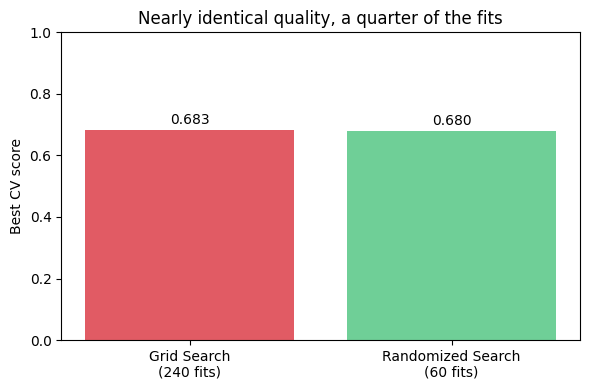

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
methods = ["Grid Search\n(240 fits)", "Randomized Search\n(60 fits)"]
scores = [grid.best_score_, random_search.best_score_]
ax.bar(methods, scores, color=["#E15B64", "#6FCF97"])
ax.set_ylabel("Best CV score")
ax.set_ylim(0, 1)
ax.set_title("Nearly identical quality, a quarter of the fits")
for i, s in enumerate(scores):
    ax.text(i, s + 0.02, f"{s:.3f}", ha="center")
plt.tight_layout(); plt.show()